# Homework 2

**Name**: Gene Kung

**UID**: 305955388

Note: Please remember to make a copy of this colab notebook in your drive.

In [33]:
# Download a processed version of the data
!wget  https://huggingface.co/hk/hw1/resolve/main/mushroom.txt

--2025-11-12 02:54:19--  https://huggingface.co/hk/hw1/resolve/main/mushroom.txt
Resolving huggingface.co (huggingface.co)... 3.174.238.90, 3.174.238.17, 3.174.238.119, ...
Connecting to huggingface.co (huggingface.co)|3.174.238.90|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/models/hk/hw1/d23e2ca56c2eb67af93a318c77348b936dcf4d12/mushroom.txt?%2Fhk%2Fhw1%2Fresolve%2Fmain%2Fmushroom.txt=&etag=%2212401d069edc9c3b8be14236a657b917ab324a19%22 [following]
--2025-11-12 02:54:19--  https://huggingface.co/api/resolve-cache/models/hk/hw1/d23e2ca56c2eb67af93a318c77348b936dcf4d12/mushroom.txt?%2Fhk%2Fhw1%2Fresolve%2Fmain%2Fmushroom.txt=&etag=%2212401d069edc9c3b8be14236a657b917ab324a19%22
Reusing existing connection to huggingface.co:443.
HTTP request sent, awaiting response... 200 OK
Length: 1264848 (1.2M) [text/plain]
Saving to: ‘mushroom.txt.1’

mushroom.txt.1      100%[===================>]   1.21M  3.07MB/s    in 0.4s    

2025-

In [34]:
# Use only the provided packages!
import csv
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [35]:
# load data from txt
# X.shape = (n_examples, n_features), y.shape = (n_examples, )
def load_data(filename):
    data = pandas.read_csv(filename).to_numpy()
    n = data.shape[0]
    d = data.shape[1] - 1

    # Map strings to numbers
    X = np.zeros((n, d))
    for i in range(d):
        mapping = {name: j for j, name in enumerate(sorted(set(data[:, i+1])))}
        for j in range(n):
            X[j, i] = mapping[data[j, i+1]]
    mapping = {'EDIBLE': 1, 'POISONOUS': 0}
    y = np.zeros(n, dtype=np.int32)
    for j in range(n):
        y[j] = mapping[data[j, 0]]

    # We only use these 6 features
    features = [0, 2, 8, 10, 15, 17]
    X = np.take(X, features, axis=-1)

    return X, y

In [36]:
def create_data(filename, test_size=0.15, val_size=0.15):
    # Load the dataset
    X, y = load_data(filename='mushroom.txt')

    # Split into train, validation, test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_size, random_state=42)
    X_train, X_val, X_test = torch.Tensor(X_train), torch.Tensor(X_val), torch.Tensor(X_test)
    y_train = torch.Tensor(np.array([ [y] for y in y_train ]))
    y_val = torch.Tensor(np.array([ [y] for y in y_val ]))
    y_test = torch.Tensor(np.array([ [y] for y in y_test ]))

    return X_train, y_train, X_val, y_val, X_test, y_test

In [37]:
def get_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, train_batch_size=16, test_batch_size=32):
    ### ========== TODO : START ========== ###
    # part a: Create dataloaders for train, validation and test sets
    # TensorDataset: like a zip
    # DataLoader: Iterator for a dataset

    # 1. Create tensorDatasets for each split
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    test_dataset = TensorDataset(X_test, y_test)

    # 2. Create dataloaders for each dataset
    train_loader = DataLoader(dataset=train_dataset,
                              batch_size=train_batch_size,
                              shuffle=True) # shuffle training data for better learning
    val_loader = DataLoader(dataset=val_dataset,
                            batch_size=test_batch_size,
                            shuffle=False)
    test_loader = DataLoader(dataset=test_dataset,
                             batch_size=test_batch_size,
                             shuffle=False)

    ### ========== TODO : END ========== ###

    return train_loader, val_loader, test_loader

In [38]:
def evaluate_loss(model, criterion, dataloader):
    model.eval()
    total_loss = 0.0
    for batch_X, batch_y in dataloader:
        batch_size = len(batch_X)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        total_loss += loss.item()

    return total_loss / len(dataloader.dataset)

In [39]:
def evaluate_acc(model, dataloader):
    model.eval()
    total_acc = 0.0
    for batch_X, batch_y in dataloader:
        outputs = model(batch_X)
        predictions = (outputs > 0.5).long()
        total_acc += (predictions==batch_y).sum()

    return total_acc / len(dataloader.dataset)

In [40]:
######################################################################
# OneLayerNetwork -- ALSO A LOGISTIC REGRESSION MODEL
######################################################################

class OneLayerNetwork(torch.nn.Module):
    def __init__(self, input_features):
        # input_features: int
        super(OneLayerNetwork, self).__init__()

        ### ========== TODO : START ========== ###
        ### part c: implement OneLayerNetwork with torch.nn.Linear. Use sigmoid as the activation

        # Set out_features=1, we want a single output value for the single linear layer
        self.linear_layer = torch.nn.Linear(input_features, 1)

        # sigmoid activation function
        self.sigmoid = torch.nn.Sigmoid()

        ### ========== TODO : END ========== ###

    def forward(self, x):
        # x.shape = (n_batch, n_features)

        ### ========== TODO : START ========== ###
        ### part c: implement the foward function

        # pass the x input through the linear layer
        logits = self.linear_layer(x)

        # pass the logits into the activation function
        outputs = self.sigmoid(logits)

        ### ========== TODO : END ========== ###
        return outputs

In [41]:
def init_oneLayerNN(in_features, lr):
    # input_features: int -> Number of input features
    # lr: float -> Learning Rate

    ### ========== TODO : START ========== ###
    ### part d: prepare the OneLayerNetwork model, criterion, and optimizer

    # Use the model from part c
    model = OneLayerNetwork(in_features)

    # Set up a criterion with torch.nn.BCELoss with the aggregation of loss as the sum
    criterion = torch.nn.BCELoss(reduction='sum')

    # set up a stochastic gradient descent (SGD) optimizer with learning rate as a parameter using torch.optim.SGD
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    ### ========== TODO : END ========== ###
    return model, criterion, optimizer

In [42]:
######################################################################
# TwoLayerNetwork
######################################################################

class TwoLayerNetwork(torch.nn.Module):
    def __init__(self, input_features, hidden_features, first_activation='sigmoid'):
        # input_features: int -> Number of input features
        # hidden_features: int -> Size of the hidden layer
        # first_activation: str -> Activation to use for the first hidden layer

        super(TwoLayerNetwork, self).__init__()
        ### ========== TODO : START ========== ###
        ### part e: implement TwoLayerNetwork with torch.nn.Linear. Use sigmoid as the activation for both layers

        # define the first layer
        self.first_layer = torch.nn.Linear(input_features, hidden_features)

        # define the second layer
        self.second_layer = torch.nn.Linear(hidden_features, 1)

        self.sigmoid = torch.nn.Sigmoid()

        ### ========== TODO : END ========== ###

    def forward(self, x):
        # x.shape = (n_batch, n_features)

        ### ========== TODO : START ========== ###
        ### part e: implement the foward function

        first_layer_logits = self.first_layer(x)
        hidden_output = self.sigmoid(first_layer_logits)

        second_layer_logits = self.second_layer(hidden_output)
        outputs = self.sigmoid(second_layer_logits)

        ### ========== TODO : END ========== ###
        return outputs

In [43]:
def init_twoLayerNN(in_features, hidden_size, first_activation, lr):
    # input_features: int -> Number of input features
    # hidden_features: int -> Size of the hidden layer
    # first_activation: str -> Activation to use for the first hidden layer
    # lr: float -> Learning Rate

    ### ========== TODO : START ========== ###
    ### part f: prepare the TwoLayerNetwork model, criterion, and optimizer

    model = TwoLayerNetwork(in_features, hidden_size)

    criterion = torch.nn.BCELoss(reduction='sum')

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    ### ========== TODO : END ========== ###

    return model, criterion, optimizer

In [44]:
def train(model, criterion, optimizer, train_loader, valid_loader, num_epochs, logging_epochs=1):
    print("Start training model...")

    train_loss_list = []
    valid_loss_list = []
    train_acc_list = []
    valid_acc_list = []
    for epoch in range(1, num_epochs+1):
        model.train()
        for batch_X, batch_y in train_loader:
            ### ========== TODO : START ========== ###
            ### part g: Build the training paradigm - Zero out gradients, forward pass, compute loss, loss backward, update model

            # init gradients to zero for each new batch
            optimizer.zero_grad()

            # forward pass
            outputs = model(batch_X)

            # compute loss
            loss = criterion(outputs, batch_y)

            # compute gradients via backprop
            # gradient of the loss function
            loss.backward()

            # update model params
            # take a step in direction of computed gradients
            optimizer.step()

            ### ========== TODO : END ========== ###

        train_loss = evaluate_loss(model, criterion, train_loader)
        valid_loss = evaluate_loss(model, criterion, valid_loader)
        train_acc = evaluate_acc(model, train_loader)
        valid_acc = evaluate_acc(model, valid_loader)
        train_loss_list.append(train_loss)
        valid_loss_list.append(valid_loss)
        train_acc_list.append(train_acc)
        valid_acc_list.append(valid_acc)

        if logging_epochs > 0 and epoch % logging_epochs == 0:
            print(f"| epoch {epoch:2d} | train loss {train_loss:.6f} | train acc {train_acc:.6f} | valid loss {valid_loss:.6f} | valid acc {valid_acc:.6f} |")

    return train_loss_list, valid_loss_list, train_acc_list, valid_acc_list

In [45]:
# fix random seed
np.random.seed(42)
torch.manual_seed(42)

In [46]:
# Data Preparation
train_batch_size = 16
test_batch_size = 32

## Load data
X_train, y_train, X_val, y_val, X_test, y_test = create_data("mushroom.txt")

## Create data loaders
train_loader, val_loader, test_loader = get_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, train_batch_size=train_batch_size, test_batch_size=test_batch_size)

In [47]:
## Define hyperparameters
lr = 0.001
num_epochs = 50

## Init models
oneLayerNN, criterion, optimizer = init_oneLayerNN(X_train.shape[1], lr=lr)
results_one = train(oneLayerNN, criterion, optimizer, train_loader, val_loader, num_epochs=num_epochs)

Start training model...
| epoch  1 | train loss 0.557378 | train acc 0.715414 | valid loss 0.559479 | valid acc 0.715750 |
| epoch  2 | train loss 0.546404 | train acc 0.727093 | valid loss 0.543314 | valid acc 0.736253 |
| epoch  3 | train loss 0.534622 | train acc 0.735976 | valid loss 0.534198 | valid acc 0.749301 |
| epoch  4 | train loss 0.536712 | train acc 0.739102 | valid loss 0.542148 | valid acc 0.743709 |
| epoch  5 | train loss 0.528689 | train acc 0.733838 | valid loss 0.534176 | valid acc 0.735322 |
| epoch  6 | train loss 0.528647 | train acc 0.768218 | valid loss 0.535205 | valid acc 0.770736 |
| epoch  7 | train loss 0.524880 | train acc 0.758184 | valid loss 0.531868 | valid acc 0.759553 |
| epoch  8 | train loss 0.530940 | train acc 0.742556 | valid loss 0.535152 | valid acc 0.751165 |
| epoch  9 | train loss 0.521009 | train acc 0.757526 | valid loss 0.528466 | valid acc 0.762349 |
| epoch 10 | train loss 0.523456 | train acc 0.752097 | valid loss 0.530420 | valid a

In [48]:
## Define hyperparameters
lr = 0.001
hidden_size = 6
activation = 'sigmoid'
num_epochs = 50

## Init models
twoLayerNN, criterion, optimizer = init_twoLayerNN(X_train.shape[1], hidden_size, activation, lr=lr)
results_two = train(twoLayerNN, criterion, optimizer, train_loader, val_loader, num_epochs=num_epochs)

Start training model...
| epoch  1 | train loss 0.678097 | train acc 0.525909 | valid loss 0.674994 | valid acc 0.557316 |
| epoch  2 | train loss 0.663843 | train acc 0.610956 | valid loss 0.662280 | valid acc 0.623486 |
| epoch  3 | train loss 0.647194 | train acc 0.620003 | valid loss 0.643383 | valid acc 0.630941 |
| epoch  4 | train loss 0.626839 | train acc 0.685475 | valid loss 0.621754 | valid acc 0.691519 |
| epoch  5 | train loss 0.601474 | train acc 0.714591 | valid loss 0.596573 | valid acc 0.719478 |
| epoch  6 | train loss 0.574962 | train acc 0.754565 | valid loss 0.570228 | valid acc 0.767008 |
| epoch  7 | train loss 0.551367 | train acc 0.743708 | valid loss 0.548664 | valid acc 0.753961 |
| epoch  8 | train loss 0.533270 | train acc 0.751275 | valid loss 0.531942 | valid acc 0.757689 |
| epoch  9 | train loss 0.520149 | train acc 0.755058 | valid loss 0.520067 | valid acc 0.759553 |
| epoch 10 | train loss 0.509807 | train acc 0.763119 | valid loss 0.510060 | valid a

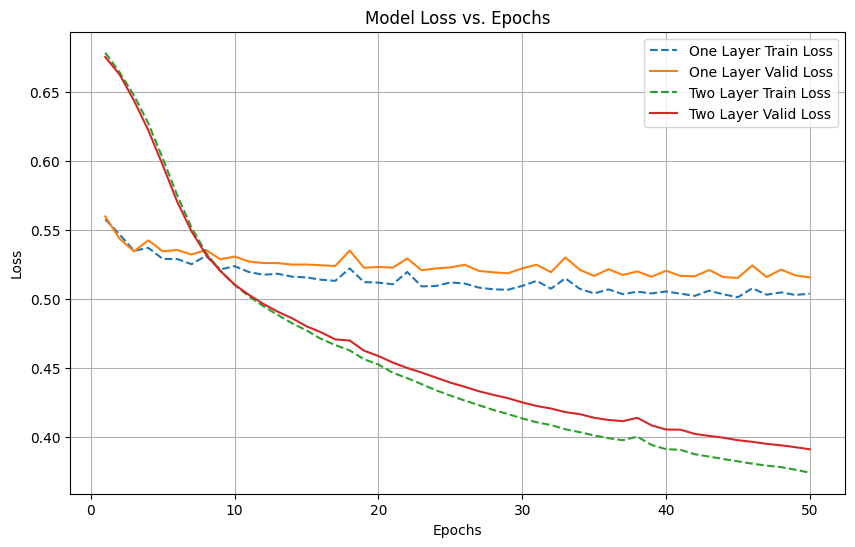

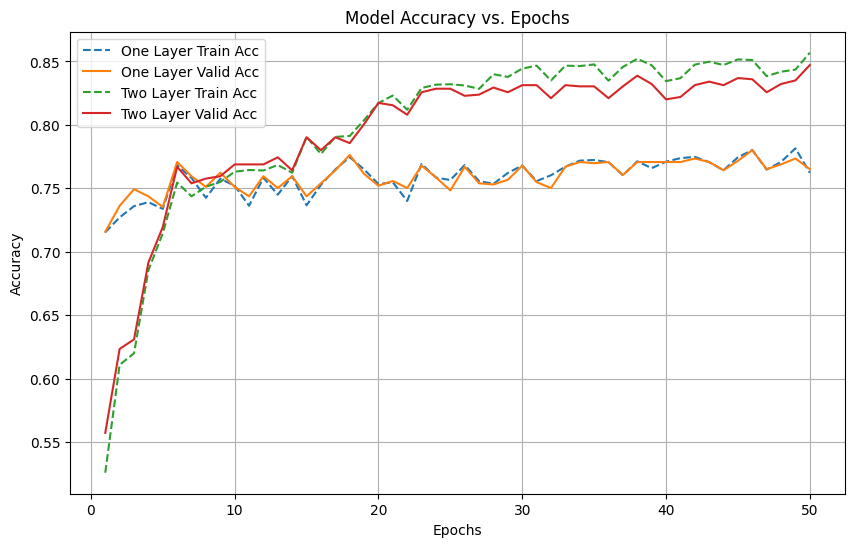

In [54]:
one_train_loss, one_valid_loss, one_train_acc, one_valid_acc = results_one
two_train_loss, two_valid_loss, two_train_acc, two_valid_acc = results_two

### ========== TODO : START ========== ###
### part h: Plot the loss for training/validation for both the models on the same curve

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, one_train_loss, label='One Layer Train Loss', linestyle='--')
plt.plot(epochs, one_valid_loss, label='One Layer Valid Loss', linestyle='-')
plt.plot(epochs, two_train_loss, label='Two Layer Train Loss', linestyle='--')
plt.plot(epochs, two_valid_loss, label='Two Layer Valid Loss', linestyle='-')

plt.title('Model Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### ========== TODO : END ========== ###

### ========== TODO : START ========== ###
### part h: Plot the accuracies for training/validation for both the models on the same curve

plt.figure(figsize=(10, 6))
plt.plot(epochs, one_train_acc, label='One Layer Train Acc', linestyle='--')
plt.plot(epochs, one_valid_acc, label='One Layer Valid Acc', linestyle='-')
plt.plot(epochs, two_train_acc, label='Two Layer Train Acc', linestyle='--')
plt.plot(epochs, two_valid_acc, label='Two Layer Valid Acc', linestyle='-')

plt.title('Model Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### ========== TODO : END ========== ###

In [56]:
### ========== TODO : START ========== ###
### part i: Evaluate the test accuracies for both the models. Explain the behavior

one_layer_test_acc = evaluate_acc(oneLayerNN, test_loader)
print(f"One-Layer Network Test Accuracy: {one_layer_test_acc:.6f}")

two_layer_test_acc = evaluate_acc(twoLayerNN, test_loader)
print(f"Two-Layer Network Test Accuracy: {two_layer_test_acc:.6f}")

### ========== TODO : END ========== ###

One-Layer Network Test Accuracy: 0.766429
Two-Layer Network Test Accuracy: 0.841647


In [74]:
def get_confusion_matrix(model, dataloader):
    ### ========== TODO : START ========== ###
    ### part j: Create confusion matrix for the given data loader

    model.eval()

    all_predictions = []
    all_true_labels = []

    with torch.no_grad(): # Disable gradient calculation for inference
      for batch_X, batch_y in dataloader:
        # Forward pass
        outputs = model(batch_X)

        # Convert probabilities to binary predictions (0 or 1)
        predictions = (outputs > 0.5).long()

        # Detach from graph, move to CPU, and convert to numpy for sklearn
        all_predictions.extend(predictions.cpu().numpy())
        all_true_labels.extend(batch_y.cpu().numpy())

    cm = confusion_matrix(all_true_labels, all_predictions)

    ### ========== TODO : END ========== ###

    return cm

In [76]:
oneLayerNN_cm = get_confusion_matrix(oneLayerNN, val_loader)
twoLayerNN_cm = get_confusion_matrix(twoLayerNN, val_loader)

print ("Confusion Matrix for One Layer NN")
print (oneLayerNN_cm)

print ("Confusion Matrix for Two Layer NN")
print (twoLayerNN_cm)

Confusion Matrix for One Layer NN
[[402 120]
 [132 419]]
Confusion Matrix for Two Layer NN
[[405 117]
 [ 47 504]]


Old Test Accuracy: 0.841647

Start training model...
| epoch  1 | train loss 0.526453 | train acc 0.724955 | valid loss 0.530905 | valid acc 0.718546 |
| epoch  2 | train loss 0.450399 | train acc 0.800132 | valid loss 0.457206 | valid acc 0.796831 |
| epoch  3 | train loss 0.417642 | train acc 0.855897 | valid loss 0.431721 | valid acc 0.844362 |
| epoch  4 | train loss 0.391901 | train acc 0.836651 | valid loss 0.408786 | valid acc 0.821994 |
| epoch  5 | train loss 0.376491 | train acc 0.842408 | valid loss 0.396586 | valid acc 0.824790 |
| epoch  6 | train loss 0.366230 | train acc 0.856720 | valid loss 0.389827 | valid acc 0.835974 |
| epoch  7 | train loss 0.379106 | train acc 0.838625 | valid loss 0.404421 | valid acc 0.817335 |
| epoch  8 | train loss 0.352379 | train acc 0.844547 | valid loss 0.377089 | valid acc 0.835042 |
| epoch  9 | train loss 0.341601 | train acc 0.861819 | valid loss 0.364837 | valid acc 0.849021 |
| epoch 10 | train loss 0.348422 | train acc 0.862806 | 

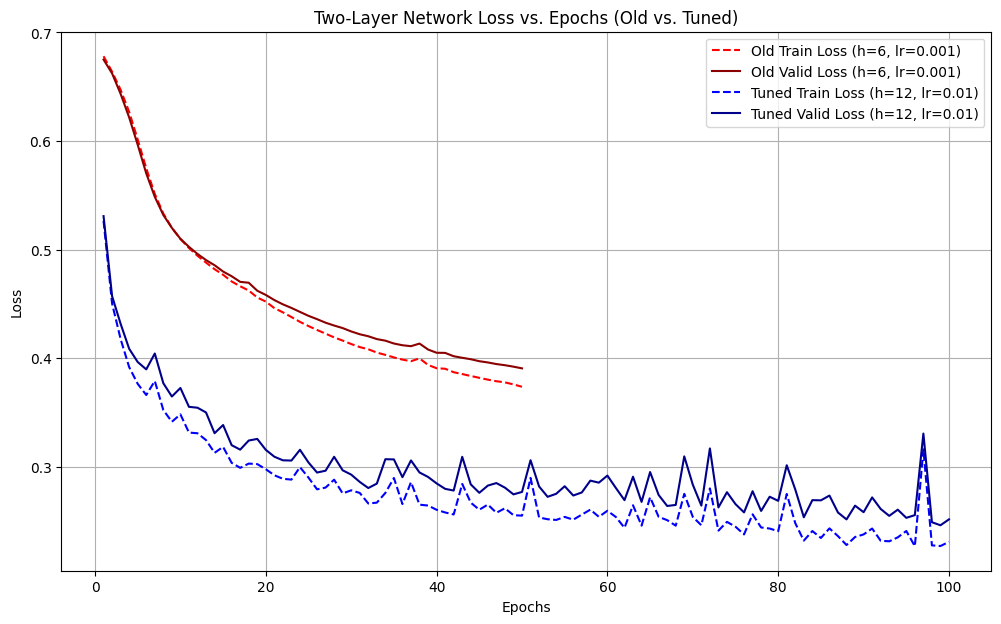

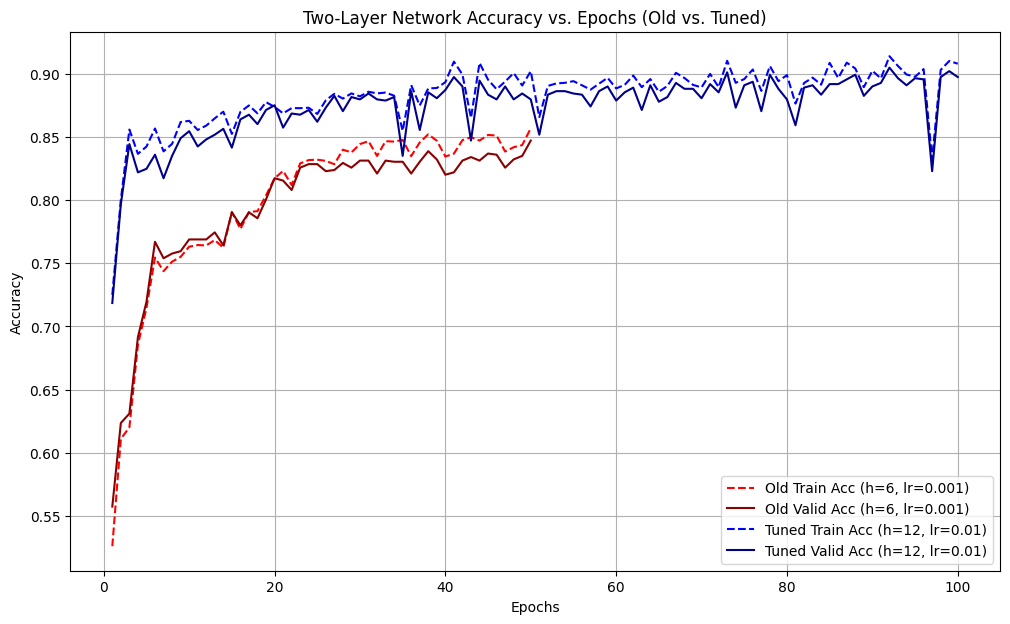

In [73]:
### ========== TODO : START ========== ###
### part k: Hyperparameter Tuning. Write your updated hyperparameter values and show improvement for the TwoLayerNetwork

old_lr = 0.001
old_hidden_size = 6
old_num_epochs = 50
print(f"Old Test Accuracy: {two_layer_test_acc:.6f}\n")

tuned_lr = 0.01         # Increased learning rate
tuned_hidden_size = 12  # Increased hidden layer size
tuned_num_epochs = 100  # Increased number of epochs to allow more learning

tuned_twoLayerNN, tuned_criterion, tuned_optimizer = init_twoLayerNN(
    X_train.shape[1],
    tuned_hidden_size,
    activation,
    lr=tuned_lr
)

tuned_results_two = train(
    tuned_twoLayerNN,
    tuned_criterion,
    tuned_optimizer,
    train_loader,
    val_loader,
    num_epochs=tuned_num_epochs
)
tuned_two_train_loss, tuned_two_valid_loss, tuned_two_train_acc, tuned_two_valid_acc = tuned_results_two

tuned_two_layer_test_acc = evaluate_acc(tuned_twoLayerNN, test_loader)
print(f"\nNew Tuned Hyperparameters:")
print(f"  Learning Rate (lr): {tuned_lr}")
print(f"  Hidden Size: {tuned_hidden_size}")
print(f"  Number of Epochs: {tuned_num_epochs}")
print(f"New Two-Layer Network Test Accuracy: {tuned_two_layer_test_acc:.6f}\n")

# --- Plotting Code with Both Old and New Curves ---

# Define X-axis ranges for both old and new epoch counts
epochs_old_range = range(1, old_num_epochs + 1)
epochs_new_range = range(1, tuned_num_epochs + 1)

# Plotting Loss
plt.figure(figsize=(12, 7))
# Old Two-Layer NN Loss curves
plt.plot(epochs_old_range, two_train_loss, label=f'Old Train Loss (h={old_hidden_size}, lr={old_lr})', linestyle='--', color='red')
plt.plot(epochs_old_range, two_valid_loss, label=f'Old Valid Loss (h={old_hidden_size}, lr={old_lr})', linestyle='-', color='darkred')
# Tuned Two-Layer NN Loss curves
plt.plot(epochs_new_range, tuned_two_train_loss, label=f'Tuned Train Loss (h={tuned_hidden_size}, lr={tuned_lr})', linestyle='--', color='blue')
plt.plot(epochs_new_range, tuned_two_valid_loss, label=f'Tuned Valid Loss (h={tuned_hidden_size}, lr={tuned_lr})', linestyle='-', color='darkblue')

plt.title('Two-Layer Network Loss vs. Epochs (Old vs. Tuned)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Accuracy
plt.figure(figsize=(12, 7))
# Old Two-Layer NN Accuracy curves
plt.plot(epochs_old_range, two_train_acc, label=f'Old Train Acc (h={old_hidden_size}, lr={old_lr})', linestyle='--', color='red')
plt.plot(epochs_old_range, two_valid_acc, label=f'Old Valid Acc (h={old_hidden_size}, lr={old_lr})', linestyle='-', color='darkred')
# Tuned Two-Layer NN Accuracy curves
plt.plot(epochs_new_range, tuned_two_train_acc, label=f'Tuned Train Acc (h={tuned_hidden_size}, lr={tuned_lr})', linestyle='--', color='blue')
plt.plot(epochs_new_range, tuned_two_valid_acc, label=f'Tuned Valid Acc (h={tuned_hidden_size}, lr={tuned_lr})', linestyle='-', color='darkblue')

plt.title('Two-Layer Network Accuracy vs. Epochs (Old vs. Tuned)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### ========== TODO : END ========== ###